0818 상대 속도 계산  
depth map에서 뽑은 깊이를 smoothing 한 후 pointcloud method 사용  

In [1]:
import numpy as np
import os

def load_npy_files(directory):
    npy_files = [f for f in os.listdir(directory) if f.endswith('metric_depth.npy')]
    data_list = []
    for file in npy_files:
        data = np.load(os.path.join(directory, file))
        data_list.append(data)
    return data_list

directory_path = 'content/object_depths'
depth_map_list = load_npy_files(directory_path)

# 로드된 데이터 확인
# for i, data in enumerate(depth_list):
#     print(f"Data {i+1}: {data}")
print(len(depth_map_list))


150


In [2]:
import cv2
cap = cv2.VideoCapture('content/test.mp4')
fps = cap.get(cv2.CAP_PROP_FPS)
cap.release()

height, width = depth_map_list[0].shape

In [3]:
print(fps)
print(height, width)

15.0
1080 1920


영상 이미지 크기와 depth map shape이 달라서 tracked_data resizing 진행  
tracked_data는 이미지 크기 기준  

In [22]:
tracked_data = np.load('content/tracker/tracked_data.npy', allow_pickle=True)
tracking_len = len(tracked_data)
print(tracking_len)

print(height, width)

img = cv2.imread('content/depth/000000_depth.png')
img_height, img_width, _ = img.shape
print(img_height, img_width)

resizing = [height/img_height, width/img_width]
print(resizing)

150
1080 1920
1080 1920
[1.0, 1.0]


In [23]:
def make_points(vehicle):
    result = [[] for _ in range(len(tracked_data))]
    for i, data in enumerate(tracked_data):
        if vehicle in data:
            points = data[vehicle]
            for garo in range(int(points[0]), int(points[2])):
                for sero in range(int(points[1]), int(points[3])):
                    point=garo, sero
                    result[i].append(point)
        else:
            center = None, None
            result[i].append(center)
    return result

In [24]:
def cal_center_points(vehicle):
    center_points = [[] for _ in range(len(tracked_data))]
    for i, data in enumerate(tracked_data):
        if vehicle in data:
            points = data[vehicle]
            v, u = (points[0]+points[2])*resizing[0]/2, (points[1]+points[3])*resizing[1]/2
            center = int(v), int(u)
            # index error 검사
            # if center[0] > width-1 or center[1] > height-1:
            #     print(f"{vehicle} {i}th frame out of range({height}, {width}): point is {points}, center is {center}")
            center_points[i].append(center)
        else:
            center = None, None
            center_points[i].append(center)
    return center_points

print(center_points[0]) - [(959, 495)]  
print(points3d_map_list[0].shape) - (921600, 3)  

### center points의 depth 추출 후 smoothing 진행  
현재 smooting은 Gaussian 필터 사용  

In [25]:
from scipy.interpolate import interp1d
def replace_short_none_gaps(values, max_gap=2):
    values = np.array(values, dtype=object)  # dtype을 object로 설정해 None 값을 포함할 수 있도록 함
    
    def is_none(value):
        return value is None  # depth 값이 None인지 확인
    
    # Identify gaps of None values that are smaller than max_gap
    i = 0
    while i < len(values):
        if is_none(values[i]):
            gap_start = i
            while i < len(values) and is_none(values[i]):
                i += 1
            gap_end = i
            
            # If gap_end is out of bounds, adjust it
            if gap_end >= len(values):
                gap_end = len(values) - 1
                
            # If gap length is less than or equal to max_gap, interpolate
            if gap_start > 0 and gap_end < len(values) and gap_end - gap_start <= max_gap:
                # gap_start-1과 gap_end의 depth 값을 사용하여 보간
                interp_func = interp1d(
                    [gap_start-1, gap_end],
                    [values[gap_start-1][2], values[gap_end][2]],
                    kind='linear',
                    fill_value="extrapolate"
                )
                interpolated_values = interp_func(np.arange(gap_start, gap_end))
                for j in range(gap_start, gap_end):
                    values[j][2] = interpolated_values[j-gap_start]
                
                if any(value[2] is None for value in values[gap_start:gap_end]):
                    print(f"None found after interpolation between indices {gap_start} and {gap_end}")
        i += 1
    
    return values

In [26]:
from scipy.ndimage import gaussian_filter1d
"""
def extract_depth(center_points):
    # extract center point depth
    centers_depth = []
    for frame_num, center in enumerate(center_points):
        v, u = center[0][0], center[0][1]
        if v is not None:
            depth = depth_map_list[frame_num]
            centers_depth.append(depth[u, v])
        else:
            centers_depth.append(None)

    # 중간에 끼어있는 None 값 제거  
    centers_depth = replace_short_none_gaps(centers_depth)
    
    # smooting
    centers_depth = np.array(centers_depth, dtype=np.float64)
    smoothed = np.where(np.isnan(centers_depth), centers_depth, gaussian_filter1d(centers_depth, sigma=2))

    smoothed_with_none = []
    for original, smoothed_value in zip(center_points, smoothed):
        if original[0][0] is None or original[0][1] is None:
            smoothed_with_none.append([None, None, None])
        else:
            smoothed_with_none.append([original[0][0], original[0][1], smoothed_value])
    
    return smoothed_with_none
"""

    

'\ndef extract_depth(center_points):\n    # extract center point depth\n    centers_depth = []\n    for frame_num, center in enumerate(center_points):\n        v, u = center[0][0], center[0][1]\n        if v is not None:\n            depth = depth_map_list[frame_num]\n            centers_depth.append(depth[u, v])\n        else:\n            centers_depth.append(None)\n\n    # 중간에 끼어있는 None 값 제거  \n    centers_depth = replace_short_none_gaps(centers_depth)\n    \n    # smooting\n    centers_depth = np.array(centers_depth, dtype=np.float64)\n    smoothed = np.where(np.isnan(centers_depth), centers_depth, gaussian_filter1d(centers_depth, sigma=2))\n\n    smoothed_with_none = []\n    for original, smoothed_value in zip(center_points, smoothed):\n        if original[0][0] is None or original[0][1] is None:\n            smoothed_with_none.append([None, None, None])\n        else:\n            smoothed_with_none.append([original[0][0], original[0][1], smoothed_value])\n    \n    return smooth

In [27]:
from scipy.ndimage import gaussian_filter1d

def extract_depth(points_list):
    # extract center point depth
    centers_depth = []
    for frame_num, points in enumerate(points_list):
        temp=[]
        for point in points:
            if point[0] is not None:
                v, u = point[0], point[1]
                depth = depth_map_list[frame_num]
                temp.append(depth[u, v])
        if (len(temp)==0):
            centers_depth.append(None)
        else :
            centers_depth.append(np.median(temp))

    ## 중간에 끼어있는 None 값 제거(필요없음)  
    ##centers_depth = replace_short_none_gaps(centers_depth)

    # smooting
    centers_depth = np.array(centers_depth, dtype=np.float64)
    # smoothed = np.where(np.isnan(centers_depth), centers_depth, gaussian_filter1d(centers_depth, sigma=2))
    smoothed = centers_depth
    smoothed_with_none = []
    for original, smoothed_value in zip(points_list, smoothed):
        if original[0][0] is None or original[0][1] is None:
            smoothed_with_none.append([None, None, None])
        else:
            smoothed_with_none.append([original[0][0], original[0][1], smoothed_value])
    
    return smoothed_with_none



### 프레임마다 velocity 구하기  
구할 수 없는 경우에는 None 값  

In [28]:
fx, fy, cx, cy = 1316.81, 738.72, 960, 540

def get_3dpoint(v, u, d):
    Z = d
    X = (v - cx) * Z / fx
    Y = (u - cy) * Z / fy
    return [X, Y, Z]

In [29]:
# 특정 포인트의 이동 거리 구하기
def cal_velocity(center_depths):
    velocity = []
    for i, depth in enumerate(center_depths):
        if i==149:
            break
        if depth[0] is None:
            velocity.append(None)
            continue
        else:
            v, u, d = depth[0], depth[1], depth[2]

            next = i
            while next < tracking_len-2 and center_depths[next][0] is None:
                next+=1
            
            try:
                nv, nu, nd = center_depths[next+1][0], center_depths[next+1][1], center_depths[next+1][2]
            except Exception as e:
                print(f"next is {next+1}/{tracking_len}: {e}")

            if nv is None:
                velocity.append(None)
                continue

            try:
                delx = np.linalg.norm(np.array(get_3dpoint(v, u, d)) - np.array(get_3dpoint(nv, nu, nd)))
                velocity.append(delx*fps/(next+1-i))
                #if delx*fps*(next+1-i) == 0:
                #    print(i, next+1)
                #    print(np.array(get_3dpoint(i, v, u)) , np.array(get_3dpoint(next+1, nv, nu)))
            except Exception as e:
                print(f"{e} v is {v} u is {u}") 
                print(f"next+1: {next+1}")
    return velocity
    

In [30]:
import json
all_vehicles = set(key for data in tracked_data for key in data.keys())
velocity_dic = {}
depth_dic = {}
for vehicle in all_vehicles:
    # center_points = cal_center_points(vehicle)
    center_points = make_points(vehicle)
    center_depths = extract_depth(center_points)
    velocity = cal_velocity(center_depths)
    print(f"{vehicle} velocity: {velocity}")
    print(len(velocity))
    depth_dic[vehicle] = center_depths
    velocity_dic[vehicle] = velocity

vehicle27 velocity: [None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, np.float64(16.483515830723316), np.float64(11.407921505135938), np.float64(3.7251753411906274), np.float64(19.514466940576845), None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None,

In [31]:
depth_dic['vehicle0']

[[1028, 465, np.float64(80.0)],
 [1028, 465, np.float64(69.4400717596736)],
 [1029, 465, np.float64(80.0)],
 [1030, 465, np.float64(29.858365432475935)],
 [1030, 465, np.float64(36.390700095754)],
 [1032, 466, np.float64(31.181447669419697)],
 [1034, 465, np.float64(61.40177986240542)],
 [1035, 464, np.float64(35.56777411510123)],
 [1036, 464, np.float64(63.9394610818465)],
 [1037, 464, np.float64(38.18707636627477)],
 [1038, 464, np.float64(32.62002096786916)],
 [1039, 464, np.float64(48.888278118971044)],
 [1040, 465, np.float64(59.91131665409014)],
 [1043, 466, np.float64(74.93141500637881)],
 [1044, 466, np.float64(59.76718514373071)],
 [1046, 465, np.float64(38.090625457321465)],
 [1048, 464, np.float64(27.362659001005795)],
 [1050, 464, np.float64(33.06497596178761)],
 [1053, 463, np.float64(80.0)],
 [1054, 463, np.float64(26.634262439731547)],
 [1055, 463, np.float64(39.67726216318705)],
 [1058, 463, np.float64(80.0)],
 [1061, 463, np.float64(57.39048155128866)],
 [1064, 463, np

: 

In [14]:
file_path = 'content/vehicle_depth.json'
with open(file_path, 'w', encoding='utf-8') as json_file:
    json.dump(depth_dic, json_file, ensure_ascii=False, indent=4)

## 결과 보정 및 visualization  
1. vehicle coordinates, ego speed 파일 로드  
2. velocity 전부 None이면 drop   
3. 좌표가 None인 vehicle 좌표 채우기  
    근처 속도로 등속운동 한다고 가정 후 좌표 계산  
    
### path와 speed visualization  
1. vehicle depth에 ego speed/fps 더함 (절대속도)  
2. 시각화


In [15]:
with open('content/vehicle_depth.json', 'r') as file:
    vehicle_coor = json.load(file)
ego_speed = np.load('content/ego_speed.npy')

vehicle27 [[None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, No

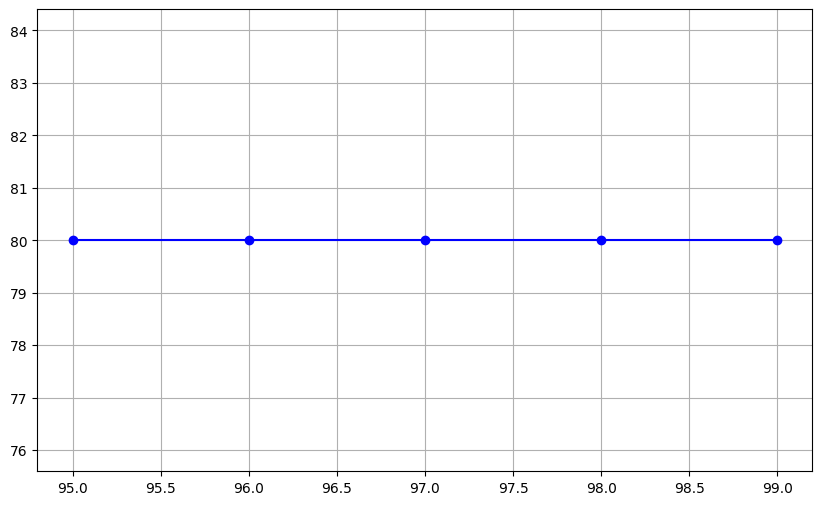

vehicle13 [[None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [910, 446, 27.390378120832544], [910, 445, 27.833827418196446], [910, 444, 33.607964774436276], [910, 444, 53.944294622405124], [910, 444, 30.092588985056373], [911, 443, 38.394505344370145], [910, 442, 53.46788262781665], [909, 440, 34.679423227898184], [908, 440, 35.415317597048805], [907, 439, 73.27935605924486], [906, 440, 31.84780052293057], [905, 440, 77.37144945137462], [904, 441

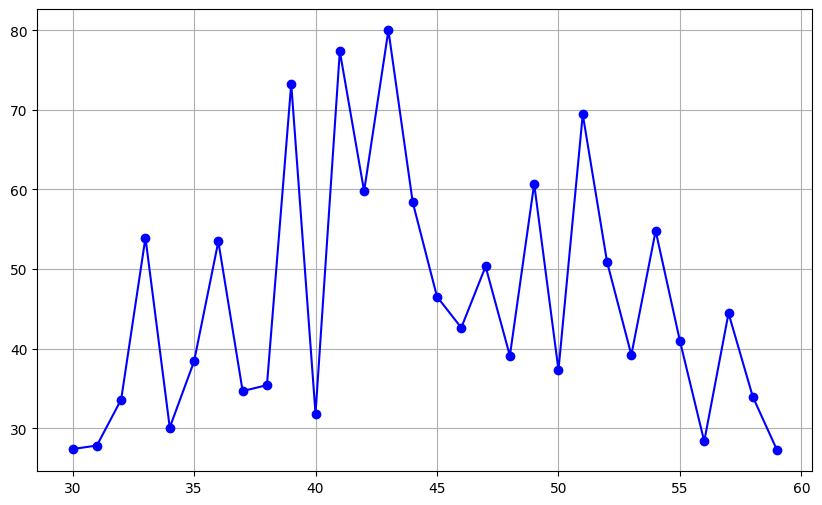

vehicle36 [[None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, No

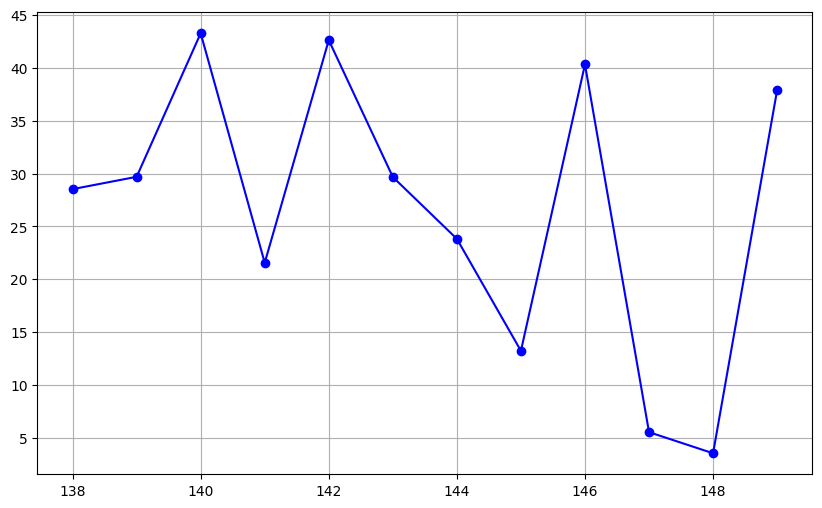

vehicle10 [[None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [752, 424, 80.0], [746, 424, 80.0], [740, 424, 80.0], [730, 424, 28.356862510285378], [724, 423, 55.49572359722134], [715, 422, 80.0], [703, 420, 41.66348940027744], [690, 417, 28.058916554396273], [670, 414, 52.76760643869847], [661, 410, 35.688516169385416], [643, 408, 61.625609311483935], [623, 403, 80.0], [599, 397, 63.82119240415189], [577, 392, 66.42486903558503], [545, 386, 41.90249921899996], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None

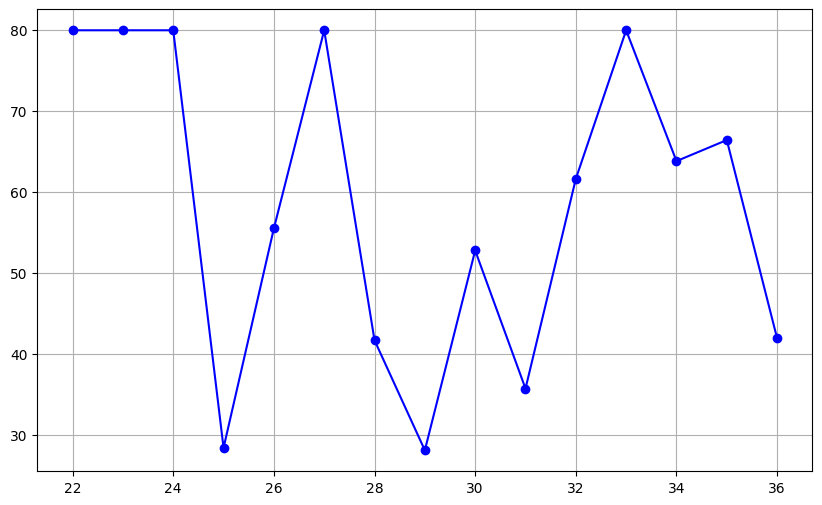

vehicle29 [[None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, No

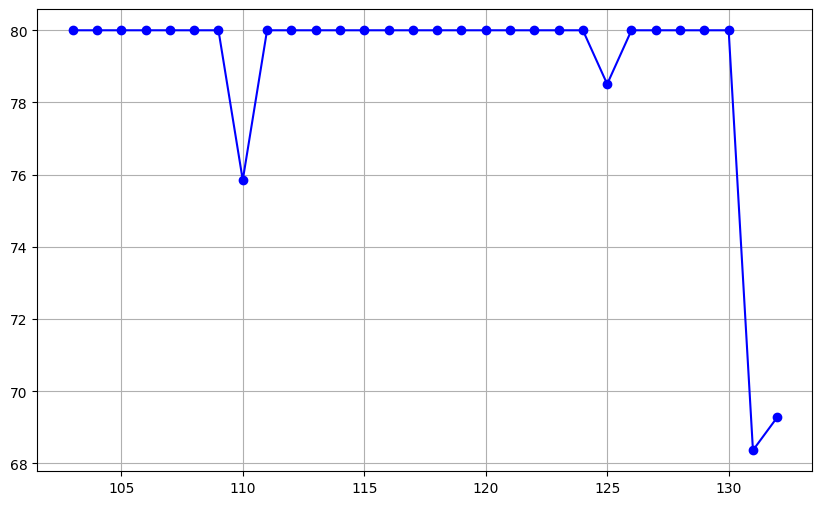

vehicle28 [[None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, No

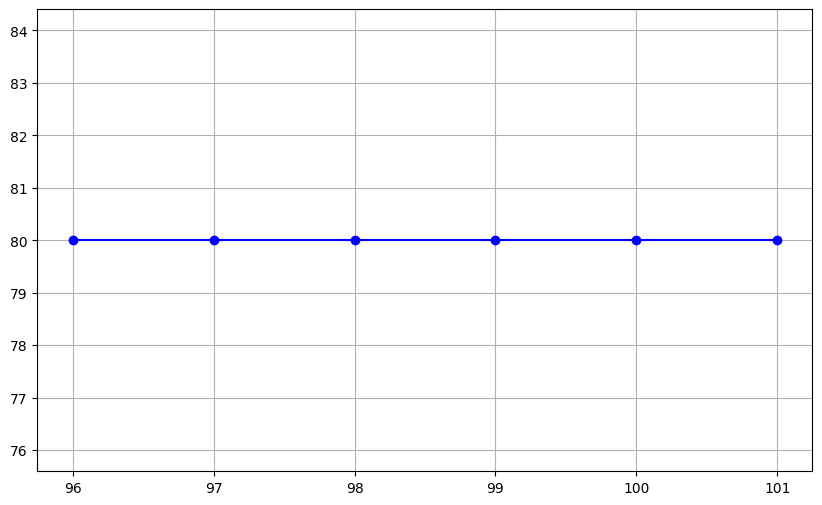

vehicle1 [[916, 460, 31.26556296116803], [916, 460, 29.845129463749757], [916, 461, 43.269674138396006], [917, 461, 24.41338551317365], [917, 461, 27.975880238634637], [917, 462, 33.31919255193267], [918, 462, 31.24749166596827], [918, 461, 30.538713991836794], [919, 461, 30.801615355517338], [918, 461, 25.78946131781174], [918, 461, 30.642677562162724], [918, 461, 29.15413649476752], [917, 461, 30.017461244539025], [918, 462, 32.045595106121056], [919, 462, 31.56118325831639], [919, 461, 34.6219336188135], [919, 460, 25.032614728770085], [919, 460, 24.56804696268786], [918, 460, 32.359153007429114], [918, 459, 24.75164025925627], [917, 458, 32.36529663743111], [917, 458, 32.47280099087405], [917, 458, 30.50059569712935], [917, 459, 30.540817215277983], [917, 460, 32.42790342612386], [917, 459, 29.6573846988206], [918, 460, 24.469488591834654], [917, 460, 31.6779134928477], [917, 461, 24.50800280452024], [917, 463, 29.873599634504448], [917, 463, 25.256110610179995], [917, 463, 24.4385

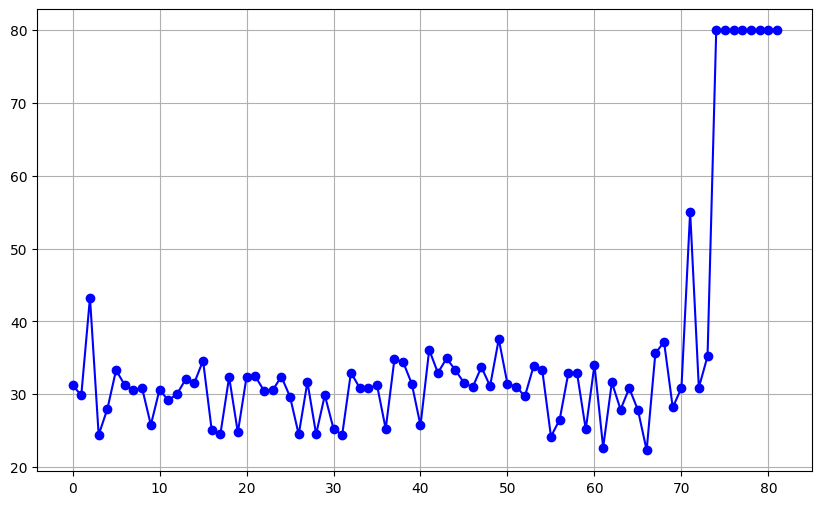

vehicle8 [[None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [915, 449, 30.90648700722794], [915, 448, 42.6846840008555], [915, 447, 42.356101144959815], [916, 446, 35.65070032508427], [917, 445, 32.43904911497751], [917, 444, 30.888735130067293], [916, 443, 59.38124691071903], [915, 442, 28.917851385718926], [914, 442, 33.64278649697026], [914, 441, 72.59340843836362], [914, 441, 58.28262997048316], [914, 441, 35.808090251341156], [912, 442, 59.452497360594755], [913, 443, 35.928164945501706], [912, 444, 34.862054977162714], [912, 444, 33.22348482419346], [911, 445, 27.49608742640049], [910, 446, 37.619688513559424], [910, 446, 30.160621709775867], [911, 447, 28.167681917623117], [911, 448, 35.80898241947409], [910, 448, 38.84651542544866], [911, 448, 31.1678608186851], [911, 447, 37.56786574484495]

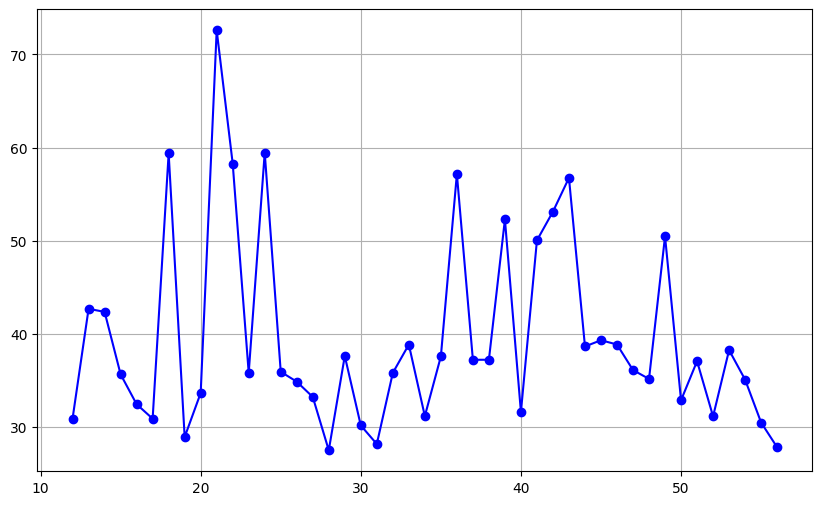

vehicle16 [[None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [489, 371, 58.264064378020336], [450, 366, 57.259925744107036], [394, 354, 80.0], [320, 338, 31.8722651754901], [293, 336, 80.0], [258, 324, 44.922426111030994], [169, 311, 80.0], [30, 283, 80.0], [None, None, None], [None, None, None], [None, None,

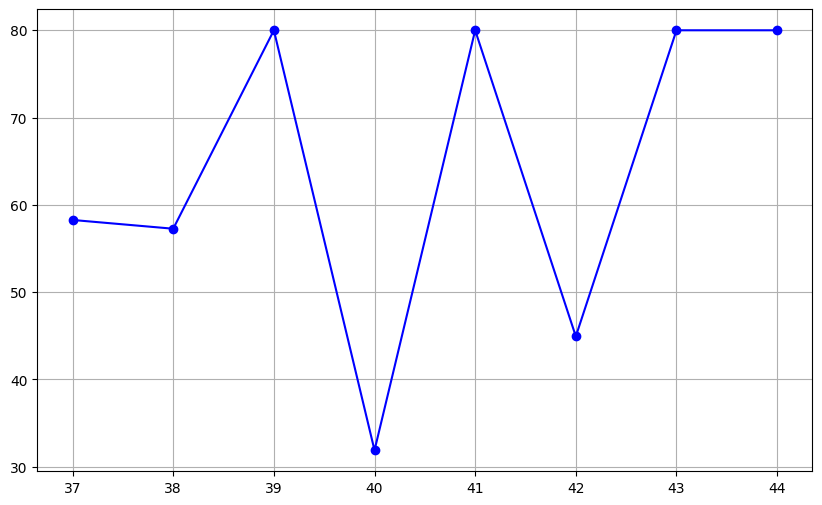

vehicle19 [[None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [960, 449, 34.08355036553041], [960, 448, 36.07751327396775], [960, 449, 37.4794010402473

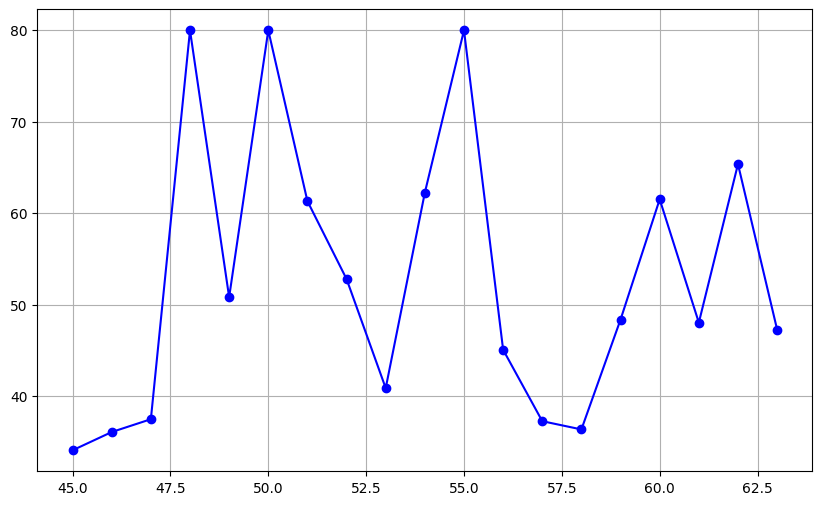

vehicle25 [[None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, No

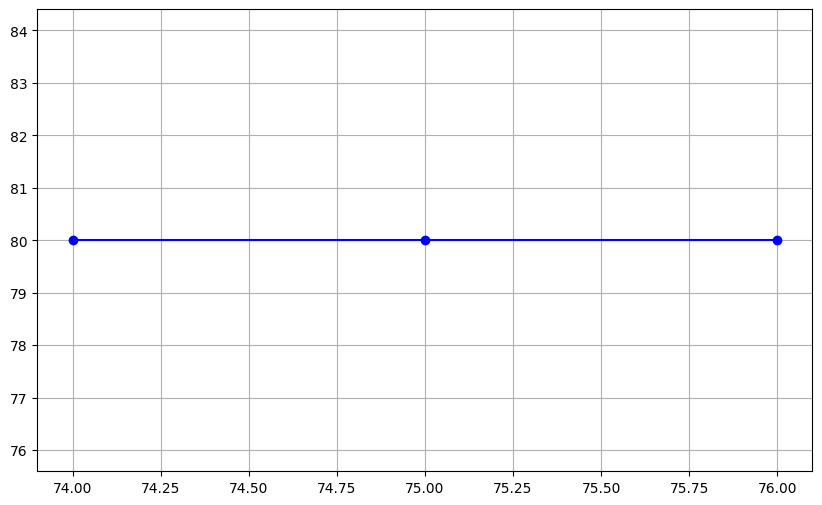

vehicle0 [[1028, 465, 80.0], [1028, 465, 69.4400717596736], [1029, 465, 80.0], [1030, 465, 29.858365432475935], [1030, 465, 36.390700095754], [1032, 466, 31.181447669419697], [1034, 465, 61.40177986240542], [1035, 464, 35.56777411510123], [1036, 464, 63.9394610818465], [1037, 464, 38.18707636627477], [1038, 464, 32.62002096786916], [1039, 464, 48.888278118971044], [1040, 465, 59.91131665409014], [1043, 466, 74.93141500637881], [1044, 466, 59.76718514373071], [1046, 465, 38.090625457321465], [1048, 464, 27.362659001005795], [1050, 464, 33.06497596178761], [1053, 463, 80.0], [1054, 463, 26.634262439731547], [1055, 463, 39.67726216318705], [1058, 463, 80.0], [1061, 463, 57.39048155128866], [1064, 463, 55.38907545035689], [1066, 463, 78.83582643324797], [1070, 463, 39.733856575666124], [1072, 464, 38.43356547336728], [1075, 464, 51.836102346460734], [1077, 465, 26.268478477189625], [1080, 466, 40.10534387606302], [1084, 467, 34.17197912533253], [1086, 467, 25.494568983793894], [1090, 467, 

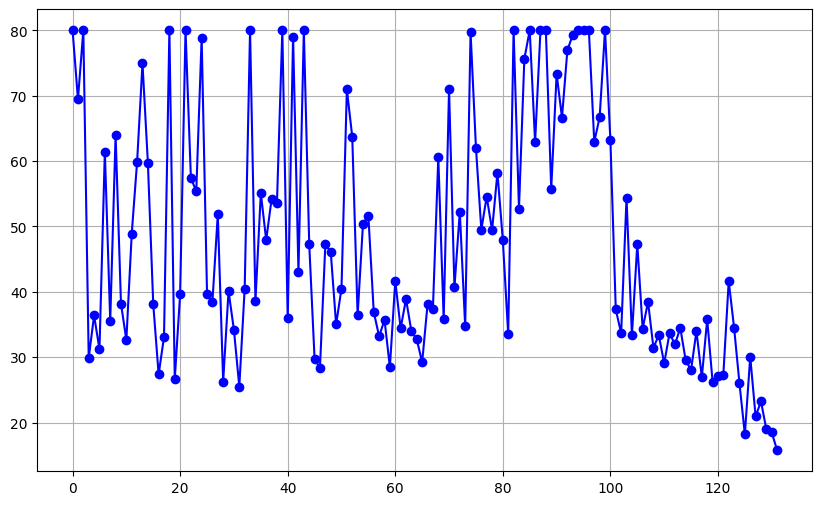

vehicle31 [[None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, No

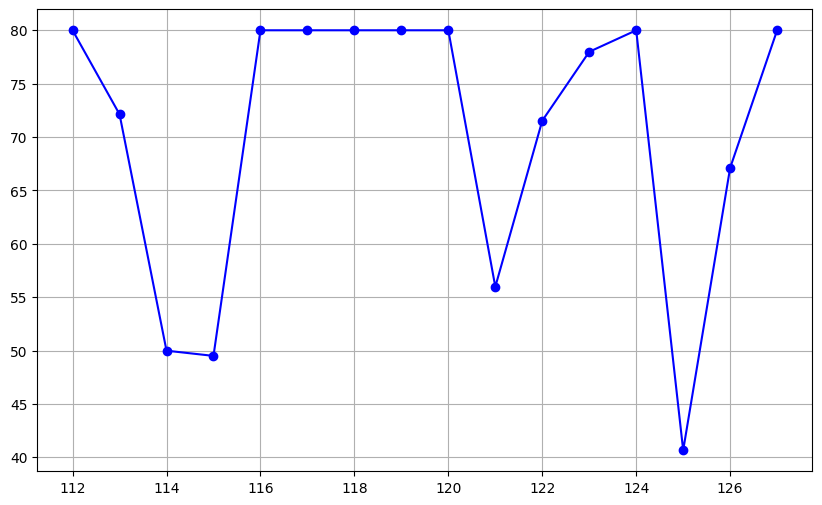

In [16]:
# drop 전 vehicle depth visualization
# None 값과 nan값 개수 확인
import matplotlib.pyplot as plt
for vehicle, coors in vehicle_coor.items():
    print(vehicle, coors)
    depths = [point[2] for point in coors]
    nan_cnt = sum(1 for d in depths if isinstance(d, float) and np.isnan(d))
    print(f'None+nan 개수: {depths.count(None)+nan_cnt}')
    print(f'nan 개수: {nan_cnt}')
    
    plt.figure(figsize=(10, 6))  
    plt.plot(depths, marker='o', linestyle='-', color='b') 
    plt.grid(True)  
    plt.show()  

In [17]:
# None, nan 개수 합이 150개이면 drop
dropped = {}
for vehicle, coors in vehicle_coor.items():
    depths = [point[2] for point in coors]
    nan_cnt = sum(1 for d in depths if isinstance(d, float) and np.isnan(d))
    if depths.count(None)+nan_cnt != len(depths):
        dropped[vehicle] = coors

print(f'{len(vehicle_coor)} {vehicle_coor.keys()}')
print(f'{len(dropped)} {dropped.keys()}')

13 dict_keys(['vehicle27', 'vehicle13', 'vehicle36', 'vehicle10', 'vehicle29', 'vehicle28', 'vehicle1', 'vehicle8', 'vehicle16', 'vehicle19', 'vehicle25', 'vehicle0', 'vehicle31'])
13 dict_keys(['vehicle27', 'vehicle13', 'vehicle36', 'vehicle10', 'vehicle29', 'vehicle28', 'vehicle1', 'vehicle8', 'vehicle16', 'vehicle19', 'vehicle25', 'vehicle0', 'vehicle31'])


vehicle27 [[None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, No

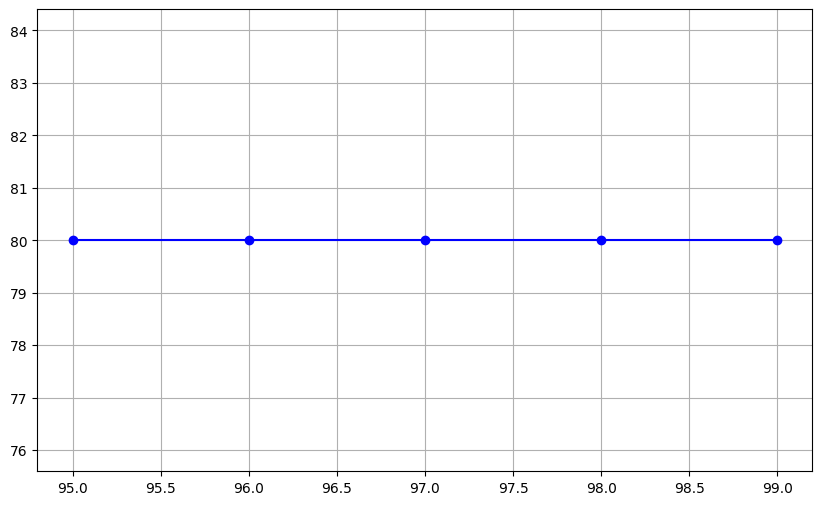

vehicle13 [[None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [910, 446, 27.390378120832544], [910, 445, 27.833827418196446], [910, 444, 33.607964774436276], [910, 444, 53.944294622405124], [910, 444, 30.092588985056373], [911, 443, 38.394505344370145], [910, 442, 53.46788262781665], [909, 440, 34.679423227898184], [908, 440, 35.415317597048805], [907, 439, 73.27935605924486], [906, 440, 31.84780052293057], [905, 440, 77.37144945137462], [904, 441

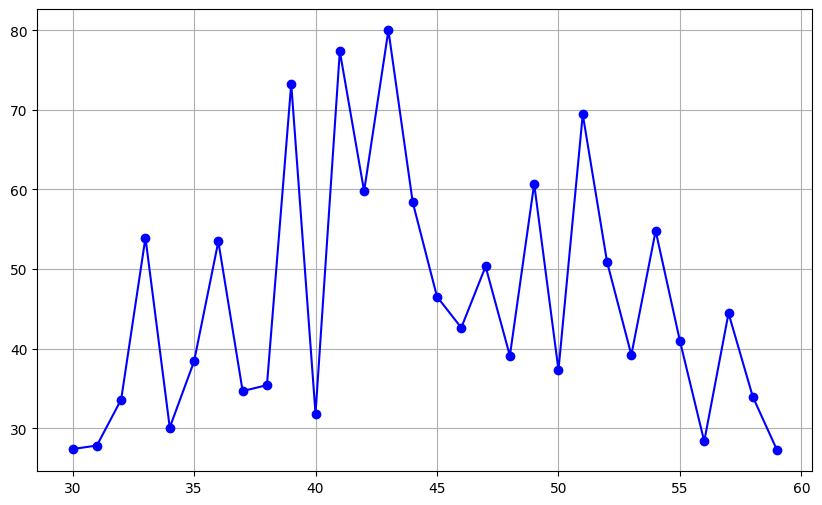

vehicle36 [[None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, No

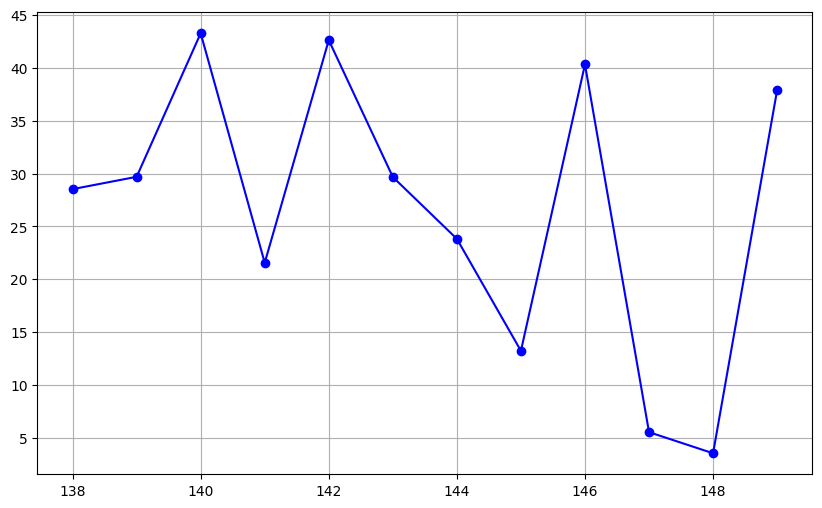

vehicle10 [[None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [752, 424, 80.0], [746, 424, 80.0], [740, 424, 80.0], [730, 424, 28.356862510285378], [724, 423, 55.49572359722134], [715, 422, 80.0], [703, 420, 41.66348940027744], [690, 417, 28.058916554396273], [670, 414, 52.76760643869847], [661, 410, 35.688516169385416], [643, 408, 61.625609311483935], [623, 403, 80.0], [599, 397, 63.82119240415189], [577, 392, 66.42486903558503], [545, 386, 41.90249921899996], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None

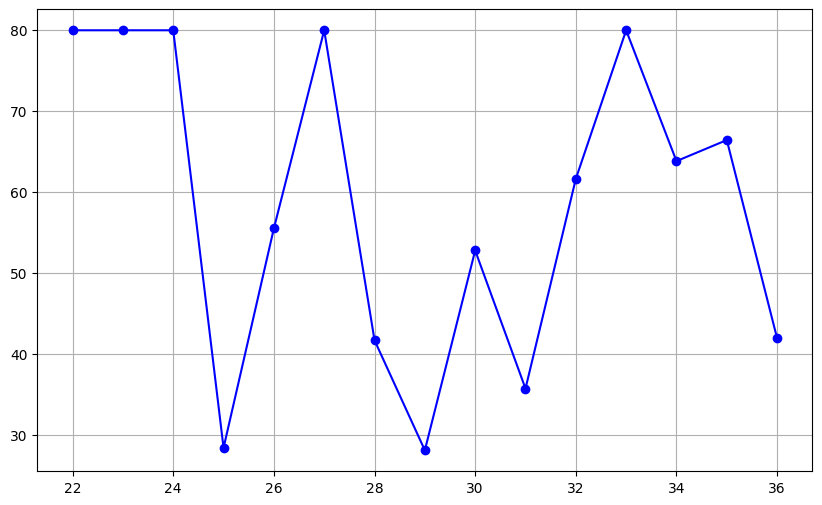

vehicle29 [[None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, No

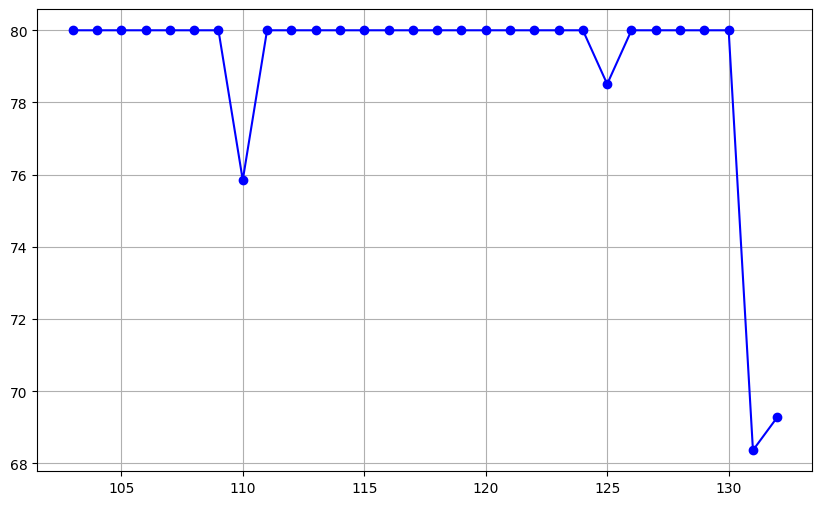

vehicle28 [[None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, No

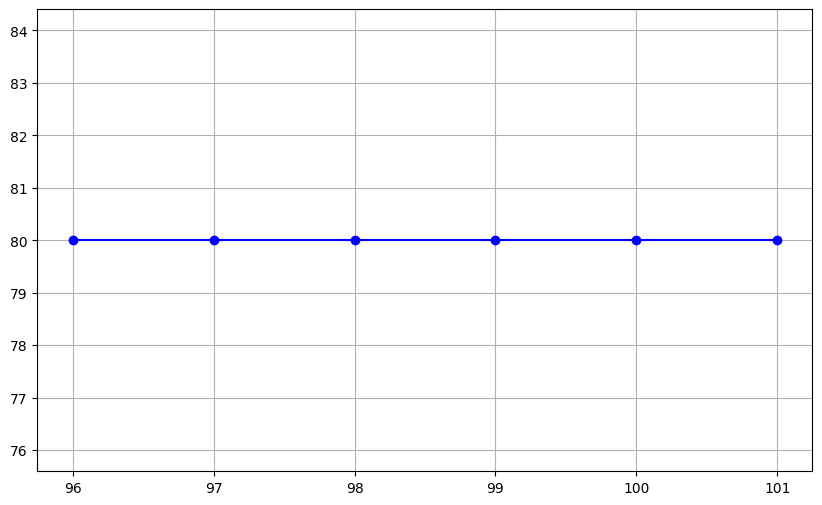

vehicle1 [[916, 460, 31.26556296116803], [916, 460, 29.845129463749757], [916, 461, 43.269674138396006], [917, 461, 24.41338551317365], [917, 461, 27.975880238634637], [917, 462, 33.31919255193267], [918, 462, 31.24749166596827], [918, 461, 30.538713991836794], [919, 461, 30.801615355517338], [918, 461, 25.78946131781174], [918, 461, 30.642677562162724], [918, 461, 29.15413649476752], [917, 461, 30.017461244539025], [918, 462, 32.045595106121056], [919, 462, 31.56118325831639], [919, 461, 34.6219336188135], [919, 460, 25.032614728770085], [919, 460, 24.56804696268786], [918, 460, 32.359153007429114], [918, 459, 24.75164025925627], [917, 458, 32.36529663743111], [917, 458, 32.47280099087405], [917, 458, 30.50059569712935], [917, 459, 30.540817215277983], [917, 460, 32.42790342612386], [917, 459, 29.6573846988206], [918, 460, 24.469488591834654], [917, 460, 31.6779134928477], [917, 461, 24.50800280452024], [917, 463, 29.873599634504448], [917, 463, 25.256110610179995], [917, 463, 24.4385

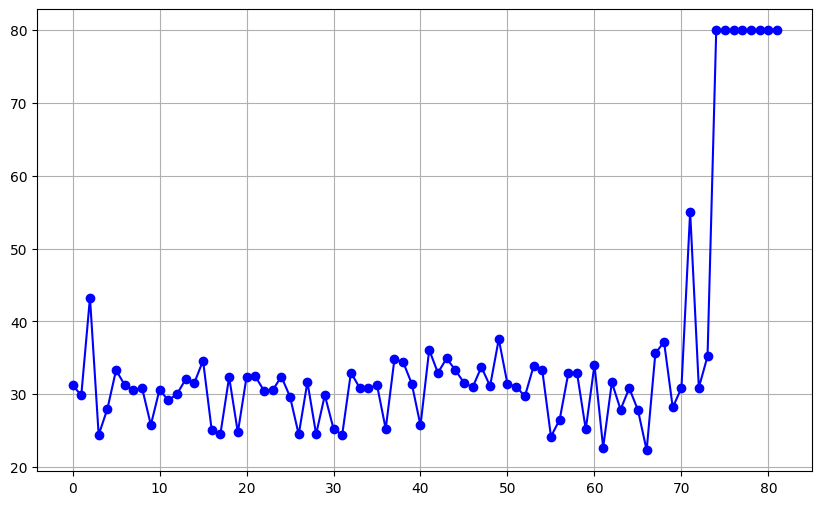

vehicle8 [[None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [915, 449, 30.90648700722794], [915, 448, 42.6846840008555], [915, 447, 42.356101144959815], [916, 446, 35.65070032508427], [917, 445, 32.43904911497751], [917, 444, 30.888735130067293], [916, 443, 59.38124691071903], [915, 442, 28.917851385718926], [914, 442, 33.64278649697026], [914, 441, 72.59340843836362], [914, 441, 58.28262997048316], [914, 441, 35.808090251341156], [912, 442, 59.452497360594755], [913, 443, 35.928164945501706], [912, 444, 34.862054977162714], [912, 444, 33.22348482419346], [911, 445, 27.49608742640049], [910, 446, 37.619688513559424], [910, 446, 30.160621709775867], [911, 447, 28.167681917623117], [911, 448, 35.80898241947409], [910, 448, 38.84651542544866], [911, 448, 31.1678608186851], [911, 447, 37.56786574484495]

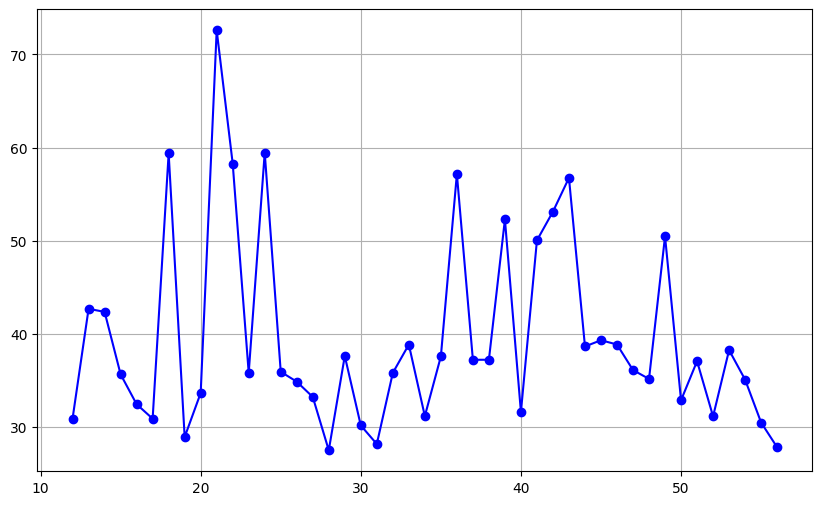

vehicle16 [[None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [489, 371, 58.264064378020336], [450, 366, 57.259925744107036], [394, 354, 80.0], [320, 338, 31.8722651754901], [293, 336, 80.0], [258, 324, 44.922426111030994], [169, 311, 80.0], [30, 283, 80.0], [None, None, None], [None, None, None], [None, None,

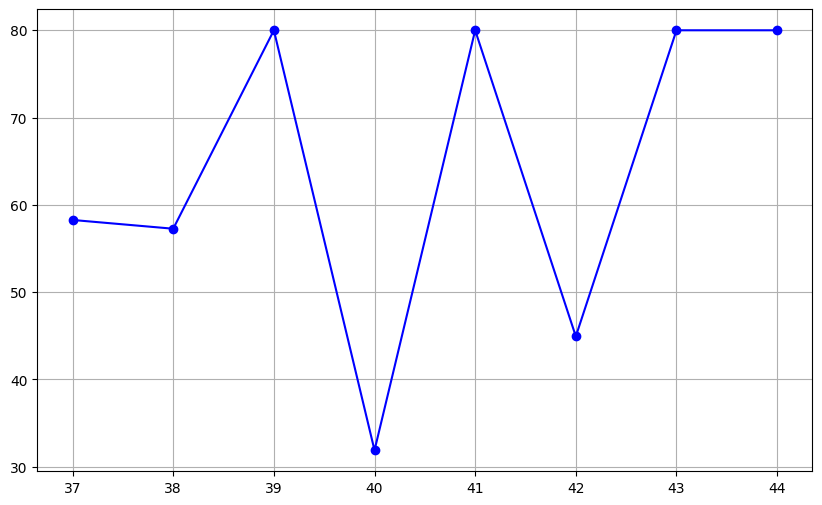

vehicle19 [[None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [960, 449, 34.08355036553041], [960, 448, 36.07751327396775], [960, 449, 37.4794010402473

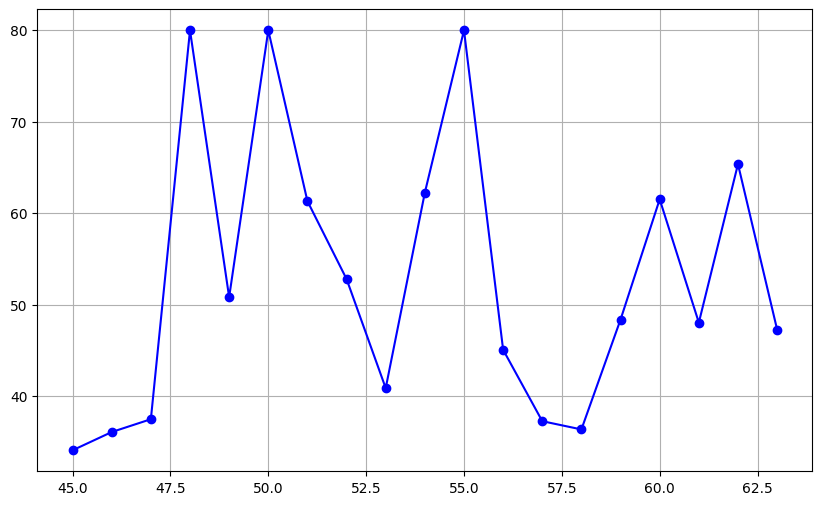

vehicle25 [[None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, No

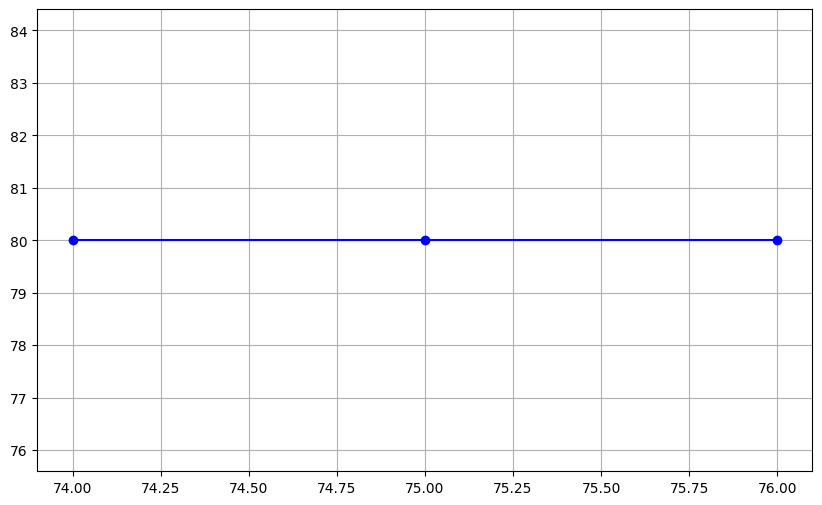

vehicle0 [[1028, 465, 80.0], [1028, 465, 69.4400717596736], [1029, 465, 80.0], [1030, 465, 29.858365432475935], [1030, 465, 36.390700095754], [1032, 466, 31.181447669419697], [1034, 465, 61.40177986240542], [1035, 464, 35.56777411510123], [1036, 464, 63.9394610818465], [1037, 464, 38.18707636627477], [1038, 464, 32.62002096786916], [1039, 464, 48.888278118971044], [1040, 465, 59.91131665409014], [1043, 466, 74.93141500637881], [1044, 466, 59.76718514373071], [1046, 465, 38.090625457321465], [1048, 464, 27.362659001005795], [1050, 464, 33.06497596178761], [1053, 463, 80.0], [1054, 463, 26.634262439731547], [1055, 463, 39.67726216318705], [1058, 463, 80.0], [1061, 463, 57.39048155128866], [1064, 463, 55.38907545035689], [1066, 463, 78.83582643324797], [1070, 463, 39.733856575666124], [1072, 464, 38.43356547336728], [1075, 464, 51.836102346460734], [1077, 465, 26.268478477189625], [1080, 466, 40.10534387606302], [1084, 467, 34.17197912533253], [1086, 467, 25.494568983793894], [1090, 467, 

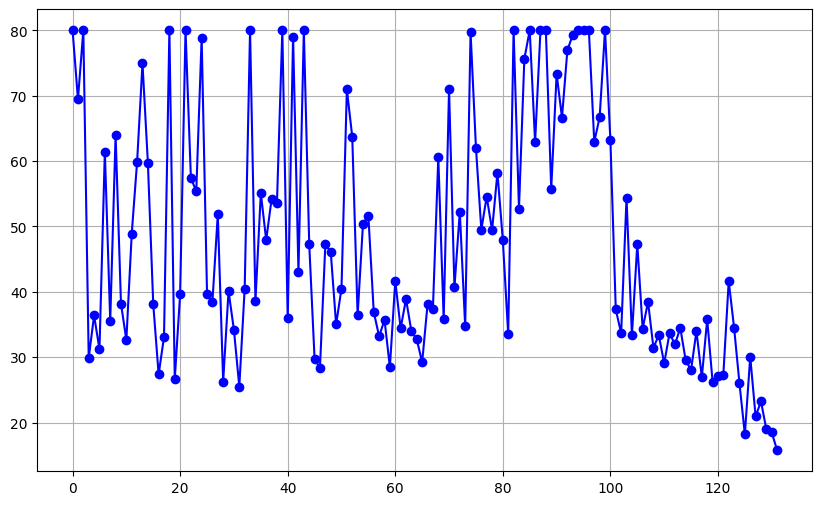

vehicle31 [[None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, No

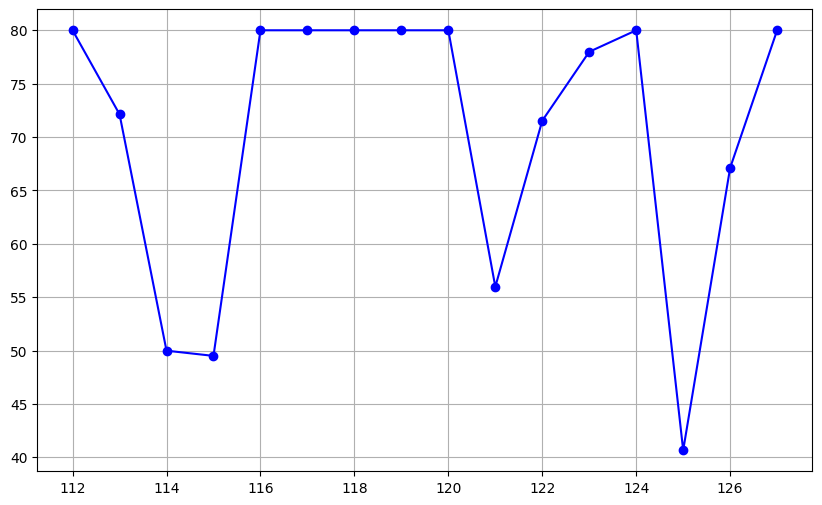

In [18]:
# dropped re visualization
import matplotlib.pyplot as plt
for vehicle, coors in dropped.items():
    print(vehicle, coors)
    depths = [point[2] for point in coors]
    nan_cnt = sum(1 for d in depths if isinstance(d, float) and np.isnan(d))
    print(f'None+nan 개수: {depths.count(None)+nan_cnt}')
    print(f'nan 개수: {nan_cnt}')
    
    plt.figure(figsize=(10, 6))  
    plt.plot(depths, marker='o', linestyle='-', color='b') 
    plt.grid(True)  
    plt.show() 

In [19]:
# velocity dic에서 None값 평균값으로 치환
vel_without_None = {}
for vehicle in dropped.keys():
    cleaned_data = [x for x in velocity_dic[vehicle] if x is not None and not (isinstance(x, float) and np.isnan(x))]
    # print(cleaned_data)
    mean = np.mean(cleaned_data)
    print(vehicle, mean)
    filled_velocity = [mean if x is None or np.isnan(x) else x for x in velocity_dic[vehicle]]
    # print(filled_velocity)
    vel_without_None[vehicle] = filled_velocity

vehicle27 12.782769904406681
vehicle13 258.4828331026895
vehicle36 296.8318207537944
vehicle10 317.29086765265447
vehicle29 15.99389580745108
vehicle28 6.197916996682665
vehicle1 76.87213194876112
vehicle8 153.73899146699392
vehicle16 493.0292407554871
vehicle19 252.20691274601754
vehicle25 4.263588975795681
vehicle0 222.0362571143303
vehicle31 191.53898420382671


vehicle27 [np.float64(12.782769904406681), np.float64(12.782769904406681), np.float64(12.782769904406681), np.float64(12.782769904406681), np.float64(12.782769904406681), np.float64(12.782769904406681), np.float64(12.782769904406681), np.float64(12.782769904406681), np.float64(12.782769904406681), np.float64(12.782769904406681), np.float64(12.782769904406681), np.float64(12.782769904406681), np.float64(12.782769904406681), np.float64(12.782769904406681), np.float64(12.782769904406681), np.float64(12.782769904406681), np.float64(12.782769904406681), np.float64(12.782769904406681), np.float64(12.782769904406681), np.float64(12.782769904406681), np.float64(12.782769904406681), np.float64(12.782769904406681), np.float64(12.782769904406681), np.float64(12.782769904406681), np.float64(12.782769904406681), np.float64(12.782769904406681), np.float64(12.782769904406681), np.float64(12.782769904406681), np.float64(12.782769904406681), np.float64(12.782769904406681), np.float64(12.782769904406681

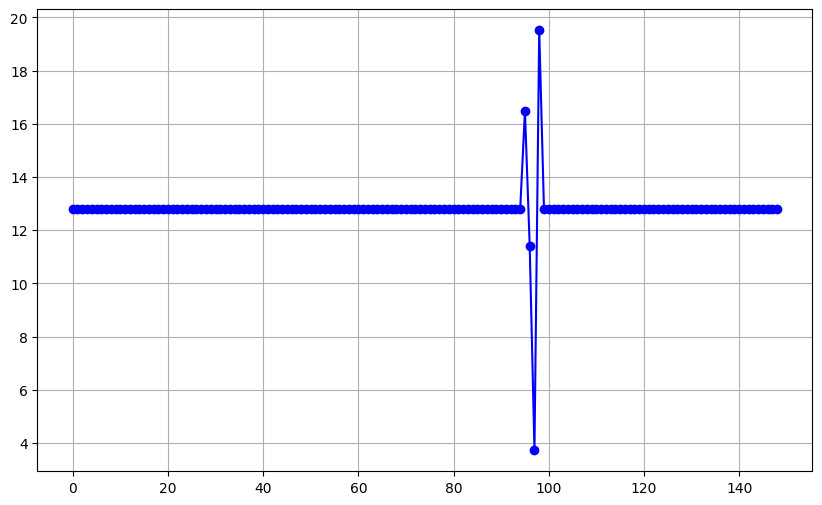

vehicle13 [np.float64(258.4828331026895), np.float64(258.4828331026895), np.float64(258.4828331026895), np.float64(258.4828331026895), np.float64(258.4828331026895), np.float64(258.4828331026895), np.float64(258.4828331026895), np.float64(258.4828331026895), np.float64(258.4828331026895), np.float64(258.4828331026895), np.float64(258.4828331026895), np.float64(258.4828331026895), np.float64(258.4828331026895), np.float64(258.4828331026895), np.float64(258.4828331026895), np.float64(258.4828331026895), np.float64(258.4828331026895), np.float64(258.4828331026895), np.float64(258.4828331026895), np.float64(258.4828331026895), np.float64(258.4828331026895), np.float64(258.4828331026895), np.float64(258.4828331026895), np.float64(258.4828331026895), np.float64(258.4828331026895), np.float64(258.4828331026895), np.float64(258.4828331026895), np.float64(258.4828331026895), np.float64(258.4828331026895), np.float64(258.4828331026895), np.float64(6.804558788333), np.float64(87.47683138758018), 

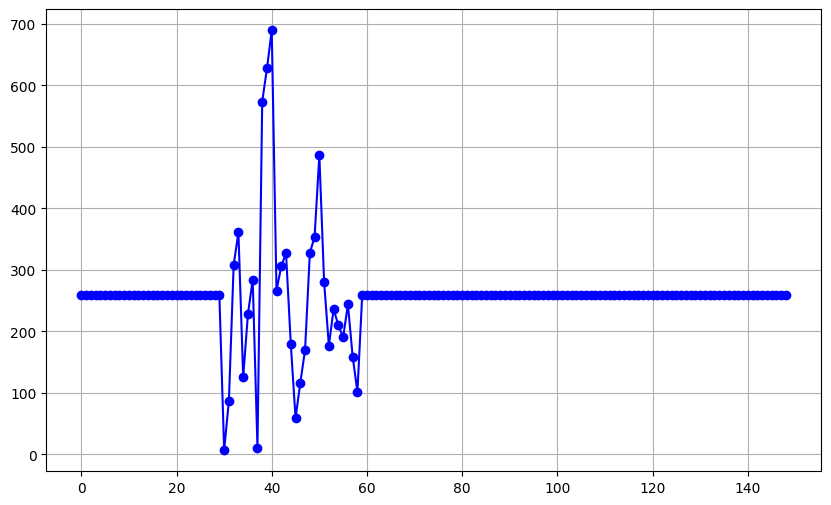

vehicle36 [np.float64(296.8318207537944), np.float64(296.8318207537944), np.float64(296.8318207537944), np.float64(296.8318207537944), np.float64(296.8318207537944), np.float64(296.8318207537944), np.float64(296.8318207537944), np.float64(296.8318207537944), np.float64(296.8318207537944), np.float64(296.8318207537944), np.float64(296.8318207537944), np.float64(296.8318207537944), np.float64(296.8318207537944), np.float64(296.8318207537944), np.float64(296.8318207537944), np.float64(296.8318207537944), np.float64(296.8318207537944), np.float64(296.8318207537944), np.float64(296.8318207537944), np.float64(296.8318207537944), np.float64(296.8318207537944), np.float64(296.8318207537944), np.float64(296.8318207537944), np.float64(296.8318207537944), np.float64(296.8318207537944), np.float64(296.8318207537944), np.float64(296.8318207537944), np.float64(296.8318207537944), np.float64(296.8318207537944), np.float64(296.8318207537944), np.float64(296.8318207537944), np.float64(296.8318207537944

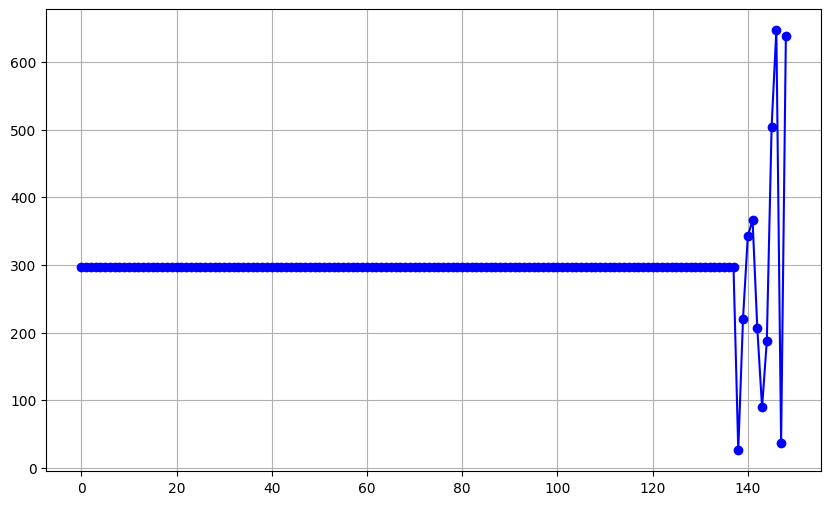

vehicle10 [np.float64(317.29086765265447), np.float64(317.29086765265447), np.float64(317.29086765265447), np.float64(317.29086765265447), np.float64(317.29086765265447), np.float64(317.29086765265447), np.float64(317.29086765265447), np.float64(317.29086765265447), np.float64(317.29086765265447), np.float64(317.29086765265447), np.float64(317.29086765265447), np.float64(317.29086765265447), np.float64(317.29086765265447), np.float64(317.29086765265447), np.float64(317.29086765265447), np.float64(317.29086765265447), np.float64(317.29086765265447), np.float64(317.29086765265447), np.float64(317.29086765265447), np.float64(317.29086765265447), np.float64(317.29086765265447), np.float64(317.29086765265447), np.float64(5.467759205959837), np.float64(5.467759205959863), np.float64(794.2284103054351), np.float64(418.99577194834006), np.float64(379.6993639574796), np.float64(590.8215706375538), np.float64(209.53525500906727), np.float64(386.43118829771396), np.float64(264.7255637661509), np.

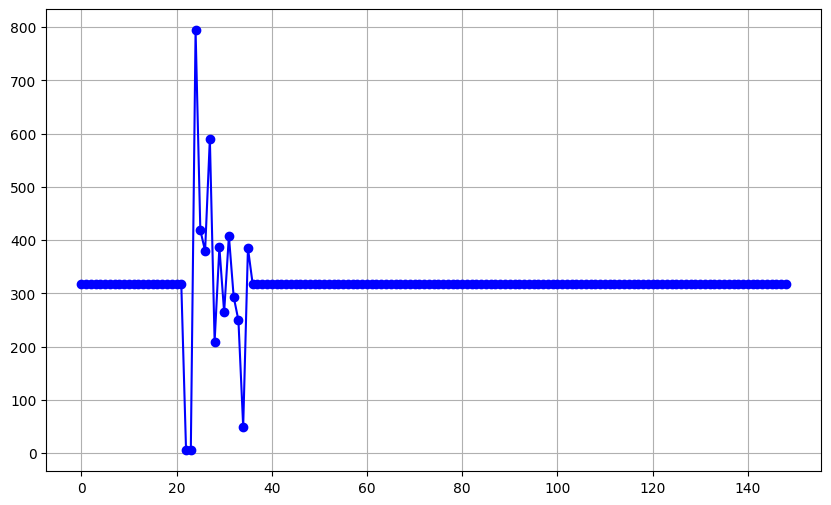

vehicle29 [np.float64(15.99389580745108), np.float64(15.99389580745108), np.float64(15.99389580745108), np.float64(15.99389580745108), np.float64(15.99389580745108), np.float64(15.99389580745108), np.float64(15.99389580745108), np.float64(15.99389580745108), np.float64(15.99389580745108), np.float64(15.99389580745108), np.float64(15.99389580745108), np.float64(15.99389580745108), np.float64(15.99389580745108), np.float64(15.99389580745108), np.float64(15.99389580745108), np.float64(15.99389580745108), np.float64(15.99389580745108), np.float64(15.99389580745108), np.float64(15.99389580745108), np.float64(15.99389580745108), np.float64(15.99389580745108), np.float64(15.99389580745108), np.float64(15.99389580745108), np.float64(15.99389580745108), np.float64(15.99389580745108), np.float64(15.99389580745108), np.float64(15.99389580745108), np.float64(15.99389580745108), np.float64(15.99389580745108), np.float64(15.99389580745108), np.float64(15.99389580745108), np.float64(15.99389580745108

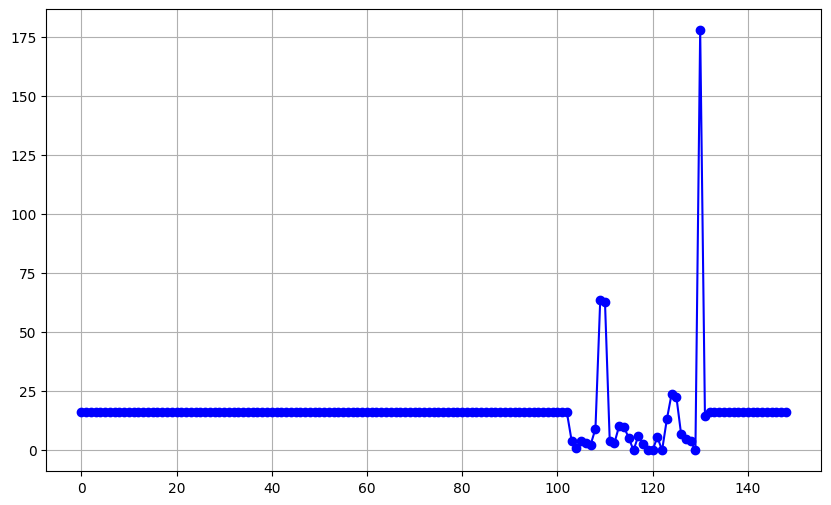

vehicle28 [np.float64(6.197916996682665), np.float64(6.197916996682665), np.float64(6.197916996682665), np.float64(6.197916996682665), np.float64(6.197916996682665), np.float64(6.197916996682665), np.float64(6.197916996682665), np.float64(6.197916996682665), np.float64(6.197916996682665), np.float64(6.197916996682665), np.float64(6.197916996682665), np.float64(6.197916996682665), np.float64(6.197916996682665), np.float64(6.197916996682665), np.float64(6.197916996682665), np.float64(6.197916996682665), np.float64(6.197916996682665), np.float64(6.197916996682665), np.float64(6.197916996682665), np.float64(6.197916996682665), np.float64(6.197916996682665), np.float64(6.197916996682665), np.float64(6.197916996682665), np.float64(6.197916996682665), np.float64(6.197916996682665), np.float64(6.197916996682665), np.float64(6.197916996682665), np.float64(6.197916996682665), np.float64(6.197916996682665), np.float64(6.197916996682665), np.float64(6.197916996682665), np.float64(6.197916996682665

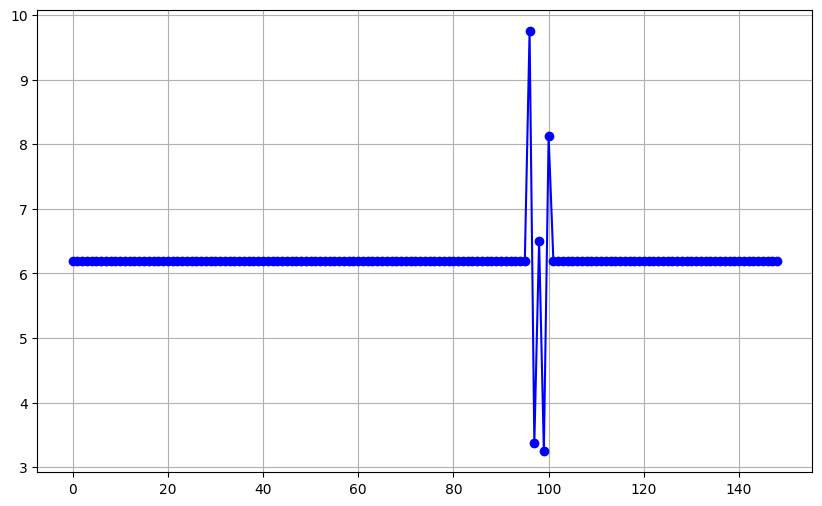

vehicle1 [np.float64(21.44290050336948), np.float64(202.56461010479694), np.float64(284.6234406210807), np.float64(53.77044355194328), np.float64(80.58008241165815), np.float64(31.278309613359202), np.float64(10.648932996033064), np.float64(3.972388599927234), np.float64(75.63870737245634), np.float64(73.25014997002819), np.float64(22.466721228455327), np.float64(13.045575783321718), np.float64(30.539603737859267), np.float64(7.330455231686253), np.float64(46.26766669054984), np.float64(144.67612832502206), np.float64(7.012617756954941), np.float64(117.6181796218021), np.float64(114.78458654986281), np.float64(115.0327791707294), np.float64(1.6233238865492219), np.float64(29.780449442113373), np.float64(0.8187714124615536), np.float64(28.426749907340373), np.float64(41.76227481664358), np.float64(78.39129391617497), np.float64(108.82527280139279), np.float64(108.28915609834507), np.float64(80.86559047741878), np.float64(69.67429909321854), np.float64(12.336912701120621), np.float64(128

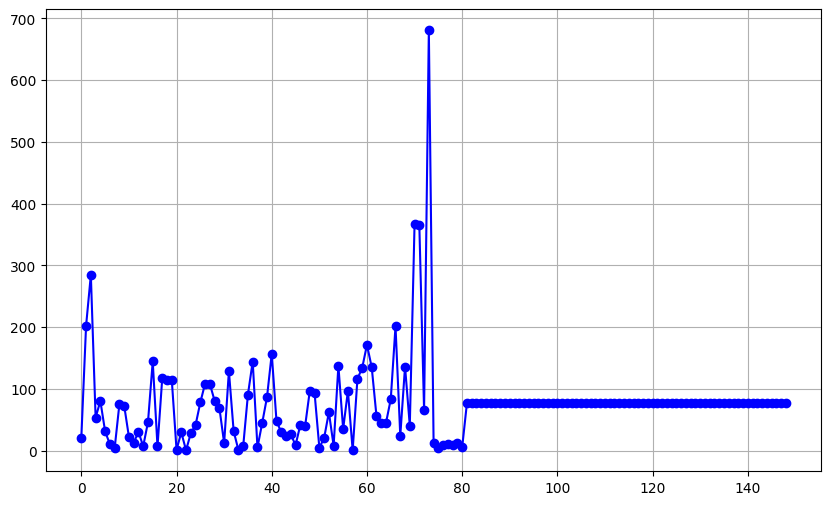

vehicle8 [np.float64(153.73899146699392), np.float64(153.73899146699392), np.float64(153.73899146699392), np.float64(153.73899146699392), np.float64(153.73899146699392), np.float64(153.73899146699392), np.float64(153.73899146699392), np.float64(153.73899146699392), np.float64(153.73899146699392), np.float64(153.73899146699392), np.float64(153.73899146699392), np.float64(153.73899146699392), np.float64(178.2187380004346), np.float64(4.9377632665818965), np.float64(101.3599572308249), np.float64(48.52485980367414), np.float64(23.38682706353864), np.float64(431.38675221405816), np.float64(461.0394603246352), np.float64(71.54998237033828), np.float64(589.9269782252643), np.float64(216.7105568603821), np.float64(340.3357845729682), np.float64(357.9424794916513), np.float64(356.30045204112673), np.float64(16.237189359924727), np.float64(24.80141448270043), np.float64(86.75287561882008), np.float64(153.12972165998727), np.float64(112.86816741362748), np.float64(30.247731972811827), np.float64

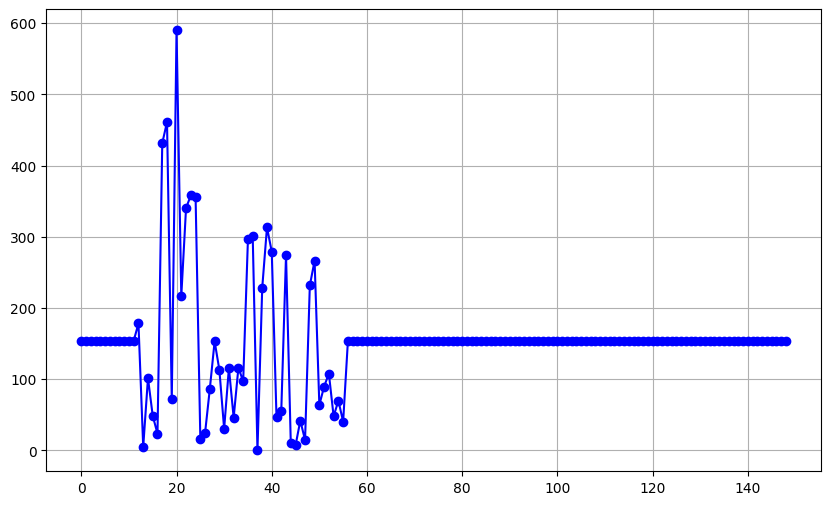

vehicle16 [np.float64(493.0292407554871), np.float64(493.0292407554871), np.float64(493.0292407554871), np.float64(493.0292407554871), np.float64(493.0292407554871), np.float64(493.0292407554871), np.float64(493.0292407554871), np.float64(493.0292407554871), np.float64(493.0292407554871), np.float64(493.0292407554871), np.float64(493.0292407554871), np.float64(493.0292407554871), np.float64(493.0292407554871), np.float64(493.0292407554871), np.float64(493.0292407554871), np.float64(493.0292407554871), np.float64(493.0292407554871), np.float64(493.0292407554871), np.float64(493.0292407554871), np.float64(493.0292407554871), np.float64(493.0292407554871), np.float64(493.0292407554871), np.float64(493.0292407554871), np.float64(493.0292407554871), np.float64(493.0292407554871), np.float64(493.0292407554871), np.float64(493.0292407554871), np.float64(493.0292407554871), np.float64(493.0292407554871), np.float64(493.0292407554871), np.float64(493.0292407554871), np.float64(493.0292407554871

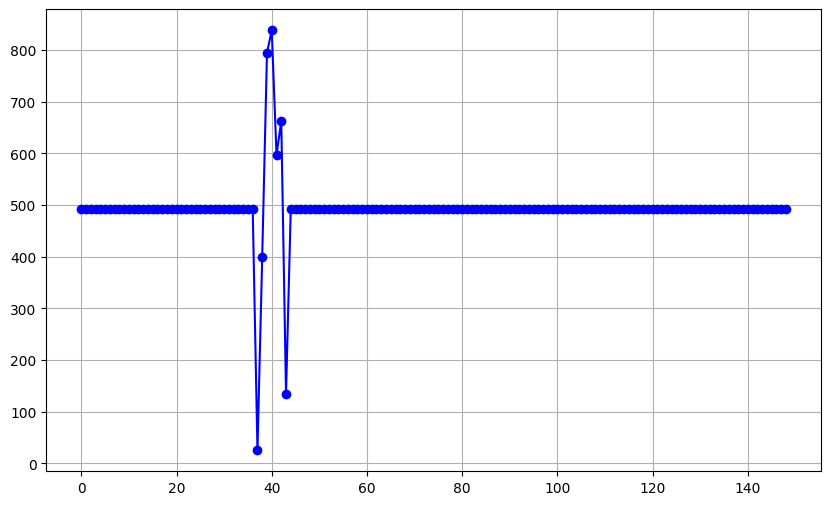

vehicle19 [np.float64(252.20691274601754), np.float64(252.20691274601754), np.float64(252.20691274601754), np.float64(252.20691274601754), np.float64(252.20691274601754), np.float64(252.20691274601754), np.float64(252.20691274601754), np.float64(252.20691274601754), np.float64(252.20691274601754), np.float64(252.20691274601754), np.float64(252.20691274601754), np.float64(252.20691274601754), np.float64(252.20691274601754), np.float64(252.20691274601754), np.float64(252.20691274601754), np.float64(252.20691274601754), np.float64(252.20691274601754), np.float64(252.20691274601754), np.float64(252.20691274601754), np.float64(252.20691274601754), np.float64(252.20691274601754), np.float64(252.20691274601754), np.float64(252.20691274601754), np.float64(252.20691274601754), np.float64(252.20691274601754), np.float64(252.20691274601754), np.float64(252.20691274601754), np.float64(252.20691274601754), np.float64(252.20691274601754), np.float64(252.20691274601754), np.float64(252.20691274601754

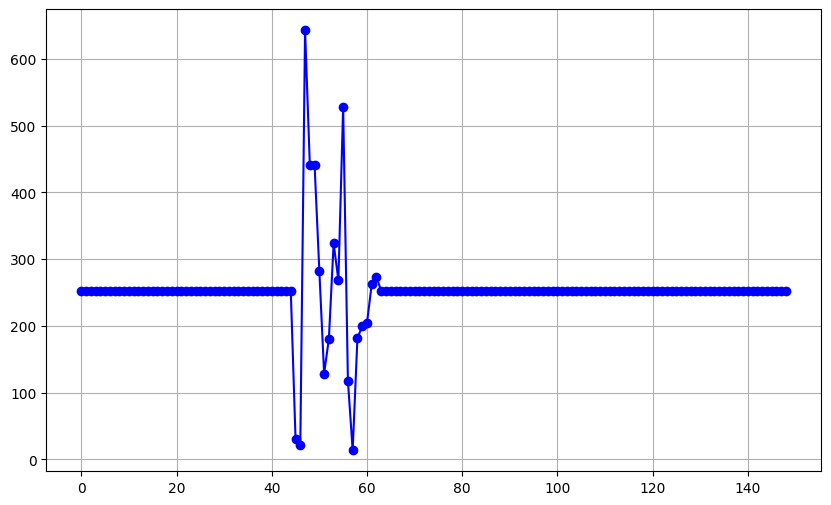

vehicle25 [np.float64(4.263588975795681), np.float64(4.263588975795681), np.float64(4.263588975795681), np.float64(4.263588975795681), np.float64(4.263588975795681), np.float64(4.263588975795681), np.float64(4.263588975795681), np.float64(4.263588975795681), np.float64(4.263588975795681), np.float64(4.263588975795681), np.float64(4.263588975795681), np.float64(4.263588975795681), np.float64(4.263588975795681), np.float64(4.263588975795681), np.float64(4.263588975795681), np.float64(4.263588975795681), np.float64(4.263588975795681), np.float64(4.263588975795681), np.float64(4.263588975795681), np.float64(4.263588975795681), np.float64(4.263588975795681), np.float64(4.263588975795681), np.float64(4.263588975795681), np.float64(4.263588975795681), np.float64(4.263588975795681), np.float64(4.263588975795681), np.float64(4.263588975795681), np.float64(4.263588975795681), np.float64(4.263588975795681), np.float64(4.263588975795681), np.float64(4.263588975795681), np.float64(4.263588975795681

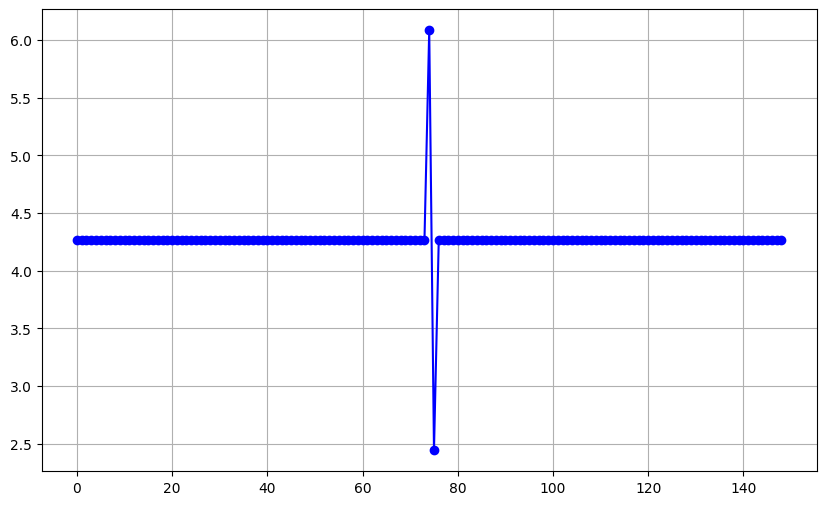

vehicle0 [np.float64(159.42317824478823), np.float64(159.47253195824075), np.float64(756.9998696928585), np.float64(98.6263680473369), np.float64(78.68232997195499), np.float64(456.4513141035082), np.float64(390.0158358085249), np.float64(428.54953013081223), np.float64(388.9394702714723), np.float64(84.06773507610404), np.float64(245.77075381294424), np.float64(166.43625251972475), np.float64(226.89358939207236), np.float64(229.00940967253104), np.float64(327.3034288651608), np.float64(161.9934999907277), np.float64(86.22926102747385), np.float64(709.7335908926958), np.float64(806.7848534398346), np.float64(197.232642251166), np.float64(609.8832285543091), np.float64(341.77384232074934), np.float64(30.186519202680508), np.float64(354.841160827245), np.float64(591.4525214884285), np.float64(19.720643479331937), np.float64(202.9782715357933), np.float64(386.99417783668474), np.float64(209.47823396846093), np.float64(89.75729480997514), np.float64(131.31526538362237), np.float64(227.2173

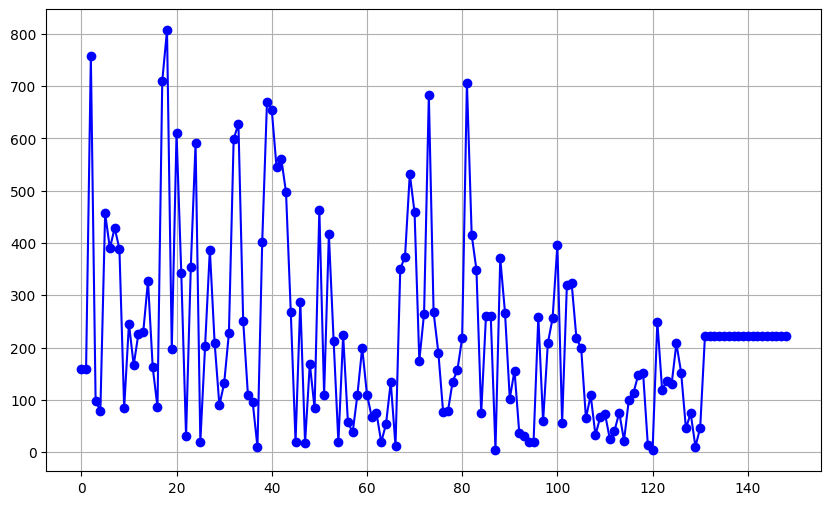

vehicle31 [np.float64(191.53898420382671), np.float64(191.53898420382671), np.float64(191.53898420382671), np.float64(191.53898420382671), np.float64(191.53898420382671), np.float64(191.53898420382671), np.float64(191.53898420382671), np.float64(191.53898420382671), np.float64(191.53898420382671), np.float64(191.53898420382671), np.float64(191.53898420382671), np.float64(191.53898420382671), np.float64(191.53898420382671), np.float64(191.53898420382671), np.float64(191.53898420382671), np.float64(191.53898420382671), np.float64(191.53898420382671), np.float64(191.53898420382671), np.float64(191.53898420382671), np.float64(191.53898420382671), np.float64(191.53898420382671), np.float64(191.53898420382671), np.float64(191.53898420382671), np.float64(191.53898420382671), np.float64(191.53898420382671), np.float64(191.53898420382671), np.float64(191.53898420382671), np.float64(191.53898420382671), np.float64(191.53898420382671), np.float64(191.53898420382671), np.float64(191.53898420382671

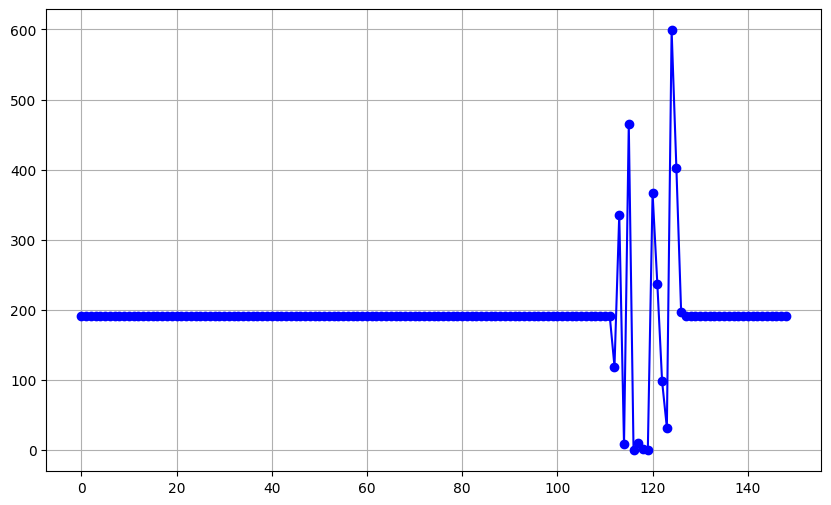

In [20]:
# filled re visualization
import matplotlib.pyplot as plt
for vehicle, coors in vel_without_None.items():
    print(vehicle, coors)
    # depths = [point[2] for point in coors]
    depths = coors
    nan_cnt = sum(1 for d in depths if isinstance(d, float) and np.isnan(d))
    print(f'None+nan 개수: {depths.count(None)+nan_cnt}')
    print(f'nan 개수: {nan_cnt}')
    
    plt.figure(figsize=(10, 6))  
    plt.plot(depths, marker='o', linestyle='-', color='b') 
    plt.grid(True)  
    plt.show() 

In [21]:
for vehicle in v

SyntaxError: expected ':' (744858305.py, line 1)

In [ ]:
idx=0
print(depth_dic.keys())
vehicle = 'vehicle0'

dict_keys(['vehicle29', 'vehicle27', 'vehicle0', 'vehicle28', 'vehicle10', 'vehicle1', 'vehicle8', 'vehicle13', 'vehicle25', 'vehicle19', 'vehicle16', 'vehicle36', 'vehicle31'])


[1028, 1028, 1029, 1030, 1030, 1032, 1034, 1035, 1036, 1037, 1038, 1039, 1040, 1043, 1044, 1046, 1048, 1050, 1053, 1054, 1055, 1058, 1061, 1064, 1066, 1070, 1072, 1075, 1077, 1080, 1084, 1086, 1090, 1094, 1098, 1104, 1106, 1109, 1113, 1117, 1122, 1124, 1129, 1134, 1140, 1147, 1150, 1153, 1156, 1156, 1155, 1154, 1152, 1150, 1145, 1130, 1121, 1111, 1102, 1094, 1084, 1080, 1073, 1065, 1056, 1041, 1035, 1023, 1010, 994, 977, 972, 962, 952, 948, 937, 932, 923, 913, 906, 898, 898, 893, 891, 892, 902, 905, 915, 920, 934, 949, 958, 977, 986, 1014, 1035, 1056, 1078, 1089, 1123, 1150, 1174, 1200, 1213, 1252, 1273, 1289, 1301, 1309, 1329, 1338, 1351, 1369, 1378, 1410, 1437, 1460, 1460, 1491, 1521, 1521, 1521, 1594, 1594, 1648, 1675, 1703, 1751, 1785, 1809, 1828, 1865, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None]
[465, 465, 465, 465, 465, 466, 465, 464, 464, 464, 464, 464, 465, 466, 466, 465, 464, 464, 463, 463, 463, 463, 463, 463, 463

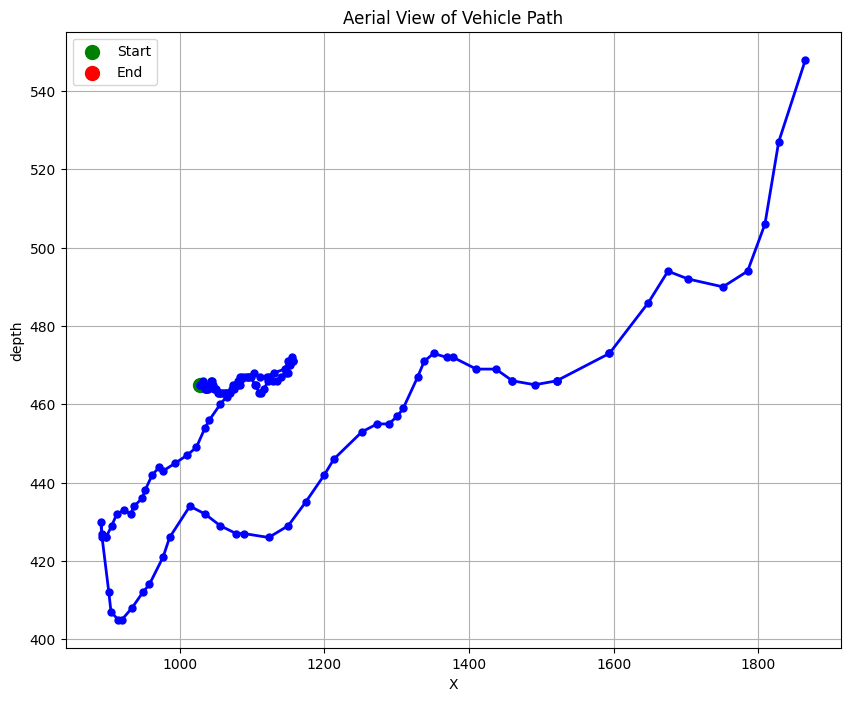

In [ ]:
import matplotlib.pyplot as plt

vehicle = 'vehicle0'
points = depth_dic[vehicle]

x = [point[0] for point in points]
y = [point[1] for point in points]
z = [point[2] for point in points]
print(x)
print(y)
print(z)

plt.figure(figsize=(10, 8))
# plt.plot(x, z, marker='o', color='b', linestyle='-', linewidth=2, markersize=5)
plt.plot(x, y, marker='o', color='b', linestyle='-', linewidth=2, markersize=5)

# plt.scatter(x[0], z[0], color='g', s=100, label='Start')
# plt.scatter(x[-1], z[-1], color='r', s=100, label='End')
plt.scatter(x[0], y[0], color='g', s=100, label='Start')
plt.scatter(x[-1], y[-1], color='r', s=100, label='End')

plt.xlabel('X')
plt.ylabel('depth')

plt.title('Aerial View of Vehicle Path')

plt.legend()

plt.grid(True)
plt.show()


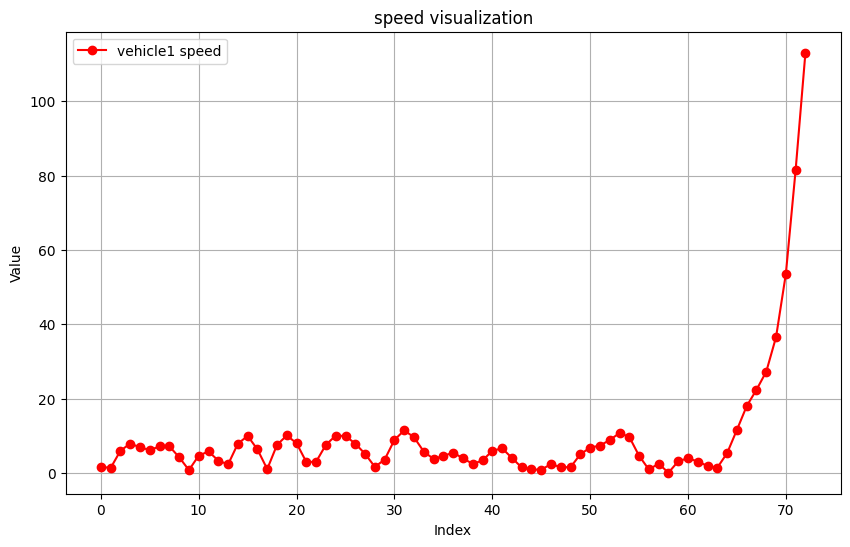

In [ ]:
import matplotlib.pyplot as plt

x = np.arange(0, len(velocity_dic['vehicle0']))
plt.figure(figsize=(10, 6))
plt.plot(x, velocity_dic['vehicle1'], color='red', marker='o', label='vehicle1 speed')
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('speed visualization')
plt.legend()
plt.grid(True)
plt.show()

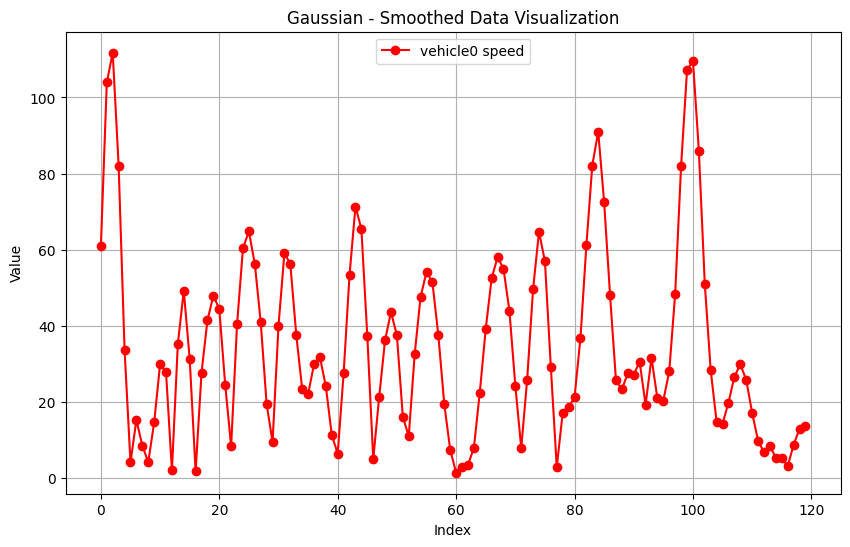

In [59]:
import matplotlib.pyplot as plt

x = np.arange(0, len(velocity_dic['vehicle0'][:120]))
plt.figure(figsize=(10, 6))
plt.plot(x, velocity_dic['vehicle0'][:120], color='red', marker='o', label='vehicle0 speed')
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Gaussian - Smoothed Data Visualization')
plt.legend()
plt.grid(True)
plt.show()

In [24]:
all_vehicles

{'vehicle0',
 'vehicle1',
 'vehicle10',
 'vehicle13',
 'vehicle16',
 'vehicle19',
 'vehicle25',
 'vehicle27',
 'vehicle28',
 'vehicle29',
 'vehicle31',
 'vehicle36',
 'vehicle8'}

In [22]:
vehicle = 'vehicle0'
center_points = cal_center_points(vehicle)
center_depths = extract_depth(center_points)
velocity = cal_velocity(center_depths)
print(f"{vehicle} velocity: {velocity}")
print(len(velocity))


num80 0
vehicle0 velocity: [np.float64(60.90629815843431), np.float64(103.92744219767675), np.float64(111.74174773892884), np.float64(81.99755648412258), np.float64(33.77469182669701), np.float64(4.150314130208609), np.float64(15.322797952652428), np.float64(8.587857904737078), np.float64(4.225548567136857), np.float64(14.658768660040462), np.float64(29.9689547620423), np.float64(27.933905280784824), np.float64(2.064804923686686), np.float64(35.28022805085972), np.float64(49.23642189294581), np.float64(31.409264873869848), np.float64(1.7967555248757672), np.float64(27.745750080713048), np.float64(41.49533093224197), np.float64(47.95032873040939), np.float64(44.471045138018354), np.float64(24.5270037555195), np.float64(8.38292740694016), np.float64(40.400139275541264), np.float64(60.4451528635234), np.float64(64.81849540042478), np.float64(56.33170470259422), np.float64(40.909367845023596), np.float64(19.411349150715008), np.float64(9.50696391320783), np.float64(40.038017898404114), np.

In [40]:
idx=0

28
1105 486
[np.float64(2.8791567928771484), np.float64(-1.9113240857171594), np.float64(26.146913492610743)]


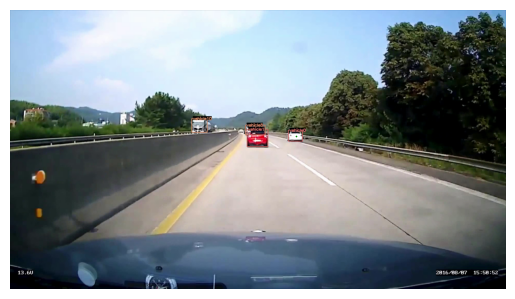

In [68]:
import random
import matplotlib.pyplot as plt
#idx = random.randint(0, tracking_len-1)
#print(idx)

idx += 1
print(idx)

v, u = center_points[idx][0][0], center_points[idx][0][1]
print(v, u)
print(get_3dpoint(idx, v, u))

img_path = f'content/tracker/{idx:06d}.png'
image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image)
plt.scatter([v], [u], color='green', s=5, edgecolor='white')
plt.axis('off')
plt.show()